In [1]:
import sys
import os
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import uuid
import warnings
import gc
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
import numpy as np
import json

from src.data_loading import load_crypto_data, preprocess_data, split_data
from src.evaluate_forecasts import evaluate_forecast_one_symbol
from models.lstm_wrapper import NeuralForecastLSTMWrapper
import os
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from config.config import DATA_DIR
import time
import uuid

DATA_DIR = os.path.join('../data')
OUTPUTS_DIR = os.path.join(DATA_DIR, 'outputs')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

In [3]:
DATA_DIR

'../data'

In [4]:
# Plotting using seaborn and matplotlib

def plot_actual_vs_forecast_for_a_symbol(symbol, plot_data):
    plt.figure(figsize=(12, 6))
    
    sns.lineplot(data=plot_data['Close'], label='Actual Close')
    if "Forecasted_Close" in plot_data.columns:
        sns.lineplot(data=plot_data['Forecasted_Close'], label='Forecasted Close')
    
    plt.title(f'{symbol} : Actual vs. Forecasted Close Values')
    plt.xlabel('Date')
    plt.ylabel('Close Value')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

In [5]:
crypto_symbols = ['BTC-USD', 'BNB-USD', 'ETH-USD', 'SOL-USD']
data_dir = DATA_DIR
train_end_date = "2023-12-31"
horizon = 30
freq = 'D'
scaling = None

In [6]:
debug = False

In [7]:
def forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 365, freq='D', scaling = None):
    """Forecasts cryptocurrency prices and saves results with weekly predictions.

    Args:
        crypto_symbols (list): List of cryptocurrency symbols.
        data_dir (str): Path to the raw data directory.
        train_end_date (str): Date string for the end of the training period.
        horizon (int): Number of next time series to be predicted
        scaling (str): "S" for standard scaler, "M" for Min Max scaler, None for no scaling

    Returns:
        dict: Dictionary containing DataFrames with actual and forecasted values.
    """
    start_time = time.time()
    uuid_name = str(uuid.uuid4())
    print(uuid_name)

    scaler = None
    if(scaling is not None and scaling.lower() == "s"):
        scaler = StandardScaler()
    elif(scaling is not None and scaling.lower() == "m"):
        scaler = MinMaxScaler()

    model = "LSTM"

        
    for symbol in crypto_symbols:

        forecaster = NeuralForecastLSTMWrapper(max_steps=20)

        file_path = os.path.join(data_dir, 'raw', f'{symbol}.csv')
        df = load_crypto_data(file_path)
        if df is None:
            continue

        processed_df  = preprocess_data(df)
        if processed_df is None:
            continue
        
        processed_df.index = processed_df.index.tz_localize(None)
        
        train_df, test_df = split_data(processed_df, train_end_date)
        
        if(debug == True):
            test_df = test_df.head(10)


        if train_df.empty:
            print(f"Warning: No training data available for {symbol}.")
            continue

        if  scaler is not None:
            scaler.fit(train_df[["Close"]])
            train_df[["Close"]] = scaler.transform(train_df[["Close"]])
            test_df[["Close"]] = scaler.transform(test_df[["Close"]])
            if(debug == True):
                print(f"train_last10\n{train_df.tail(10)}")
                print(f"Test all: {test_df}")



        # Forecast for the training data (validation)
        train_forecasts = []
        train_forecast_dates = []


        # Forecast for the test data
        test_forecasts = []
        test_forecast_dates = []
        for i in range(0, len(test_df), horizon):
            test_history = pd.concat([train_df['Close'], test_df['Close'][:i]])
            if(debug == True):
                print( f"test_history\n{test_history}")
            forecaster.fit(test_history, fh=np.arange(1, horizon + 1))   
            try:
                point_forecast, _ = forecaster.forecast(forecasting_horizon=horizon)
                test_forecasts.extend(point_forecast)
                test_forecast_dates.extend(pd.date_range(start=test_df.index[i], periods=horizon, freq='D'))
            except Exception as e:
                print(f"Error during test forecast for {symbol} at index {i}: {e}")
                break

        if train_forecasts:
            train_forecast_df = pd.DataFrame({'Close': train_forecasts}, index=train_forecast_dates)
            if scaler is not None:
                train_forecast_df["Close"] = scaler.inverse_transform(train_forecast_df[["Close"]])
            train_forecast_df.columns = ["Forecasted_Close"]
            if scaler is not None:
                train_df['Close'] = scaler.inverse_transform(train_df[['Close']])
            train_output_df = train_df[['Close']].join(train_forecast_df, how='left')
        else:
            if scaler is not None:
                train_df[['Close']] = scaler.inverse_transform(train_df[['Close']])
            train_output_df = train_df[['Close']].copy()
            train_output_df['Forecasted_Close'] = np.nan

        if test_forecasts:
            test_forecast_df = pd.DataFrame({'Close': test_forecasts[:len(test_df)]}, index=test_df.index)
            if(debug == True):
                print(f"test_forecast_df\n{test_forecast_df}")
            if scaler is not None:
                test_forecast_df["Close"] = scaler.inverse_transform(test_forecast_df[["Close"]])
                if(debug == True):
                    print(f"test_forecast_df inverse transformed\n{test_forecast_df}")
            test_forecast_df.columns = ["Forecasted_Close"]
            if(debug == True):
                print(f"test_df\n{test_df['Close']}")
            if scaler is not None:
                test_df['Close'] = scaler.inverse_transform(test_df[['Close']])
                if(debug == True):
                    print(f"test_df inverse transformed\n{test_df['Close']}")
            test_output_df = test_df[['Close']].join(test_forecast_df, how='left')
        else:
            if scaler is not None:
                test_df[['Close']] = scaler.inverse_transform(test_df[['Close']])
            test_output_df = test_df[['Close']].copy()
            test_output_df['Forecasted_Close'] = np.nan
        # Save actual and forecasted values (both train and test)
        output_file_path = os.path.join(OUTPUTS_DIR, f'{symbol}_{model}_{horizon}_{uuid_name}_forecasts.csv')

        combined_data = pd.concat([train_output_df, test_output_df])

        if scaler is not None:
            combined_data["Close_Scaled"] = scaler.transform(combined_data[['Close']])
            forecasted_df = pd.DataFrame(combined_data['Forecasted_Close'], index=combined_data.index)
            forecasted_df.columns = ["Close"]
            combined_data["Forecasted_Close_Scaled"] = scaler.transform(forecasted_df[['Close']])
        end_time = time.time()
        print(f"Execution time for forecast_crypto_prices(): {end_time - start_time} seconds")
        combined_data.to_csv(output_file_path)

        unscaled_data = combined_data[["Close", "Forecasted_Close"]].copy()
        plot_actual_vs_forecast_for_a_symbol(symbol, unscaled_data)
        eval_metrics = evaluate_forecast_one_symbol(unscaled_data.reset_index(), forecasted_value_col = "Forecasted_Close",
                                                    actual_value_col = "Close",test_data_date = "2024-01-01")
        # Writing eval metrics to json file
        json_file_path =  os.path.join(OUTPUTS_DIR, f'eval_metric_actuals_{model}_{symbol}_{uuid_name}.json')
        
        # Writing JSON data to a file
        with open(json_file_path, 'w') as file:
            json.dump(eval_metrics, file, indent=4)
        
        
        print(f"Evaluation Metric for {symbol}_{model}_{horizon} Actual Values")
        for metric, value in eval_metrics.get('test', {}).items():
            print(f"{metric}: {value}")
        
        if scaler is not None:
            scaled_data = combined_data[["Close_Scaled", "Forecasted_Close_Scaled"]].copy()
            scaled_data.columns = ["Close", "Forecasted_Close"]
            plot_actual_vs_forecast_for_a_symbol(symbol, scaled_data)
            eval_metrics = evaluate_forecast_one_symbol(scaled_data.reset_index(), forecasted_value_col = "Forecasted_Close",
                                                        actual_value_col = "Close",test_data_date = "2024-01-01")
            # Writing eval metrics to json file
            json_file_path =  os.path.join(OUTPUTS_DIR, f'eval_metric_scaled_{model}_{symbol}_{uuid_name}.json')
            
            # Writing JSON data to a file
            with open(json_file_path, 'w') as file:
                json.dump(eval_metrics, file, indent=4)
            
            print(f"Evaluation Metric for {symbol}_{model}_{horizon} Scaled")
            for metric, value in eval_metrics.get('test', {}).items():
                print(f"{metric}: {value}")

a0ac0220-273c-408d-b853-980225d8e171
Model initialized: NeuralForecastLSTM
{'batch_size': 32, 'broadcasting': False, 'context_size': 10, 'decoder_hidden_size': 200, 'decoder_layers': 2, 'drop_last_loader': False, 'early_stop_patience_steps': -1, 'encoder_bias': True, 'encoder_dropout': 0.0, 'encoder_hidden_size': 200, 'encoder_n_layers': 2, 'freq': 'YE-DEC', 'futr_exog_list': None, 'inference_input_size': -1, 'input_size': -1, 'learning_rate': 0.001, 'local_scaler_type': None, 'loss': None, 'lr_scheduler': None, 'lr_scheduler_kwargs': None, 'max_steps': 20, 'num_lr_decays': -1, 'num_workers_loader': 0, 'optimizer': None, 'optimizer_kwargs': None, 'random_seed': 1, 'scaler_type': 'robust', 'trainer_kwargs': None, 'val_check_steps': 100, 'valid_batch_size': None, 'valid_loss': None, 'verbose_fit': False, 'verbose_predict': False}


Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
2025-04-17 13:33:32.067087: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-17 13:33:32.073682: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025-04-17 13:33:32.073707: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0   

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

NeuralForecastLSTM model fitted.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

/tmp/ipykernel_242555/869719685.py:121: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_data = pd.concat([train_output_df, test_output_df])


Execution time for forecast_crypto_prices(): 25.10792851448059 seconds


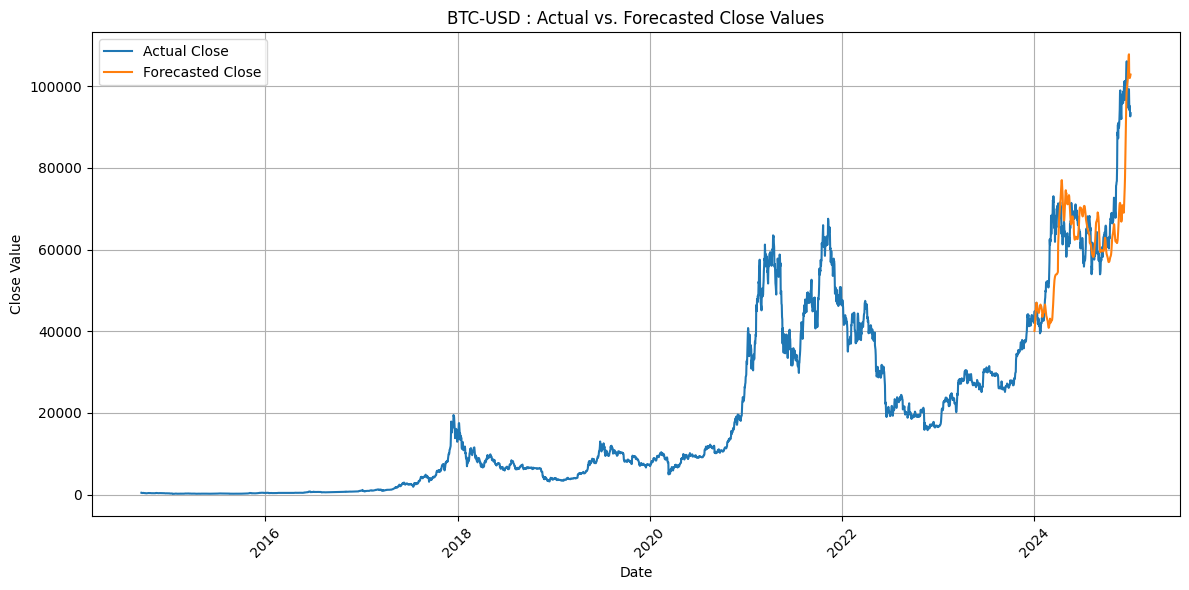

Evaluation Metric for BTC-USD_LSTM_30 Actual Values
MAPE: 11.789068624208895
ME: 3247.210275785519
MAE: 8215.172024419398
MPE: 3.575769850811276
RMSE: 11117.49109926885
R: 0.7148499438742011
Scalar Product: 58053097.30268869
Return Score: 0.547945205479452
Long Return: 0.6105263157894737
Short Return: 0.48
Mean Directional Accuracy: 0.547945205479452
Mean Directional Accuracy Positive: 0.6105263157894737
Mean Directional Accuracy Negative: 0.48


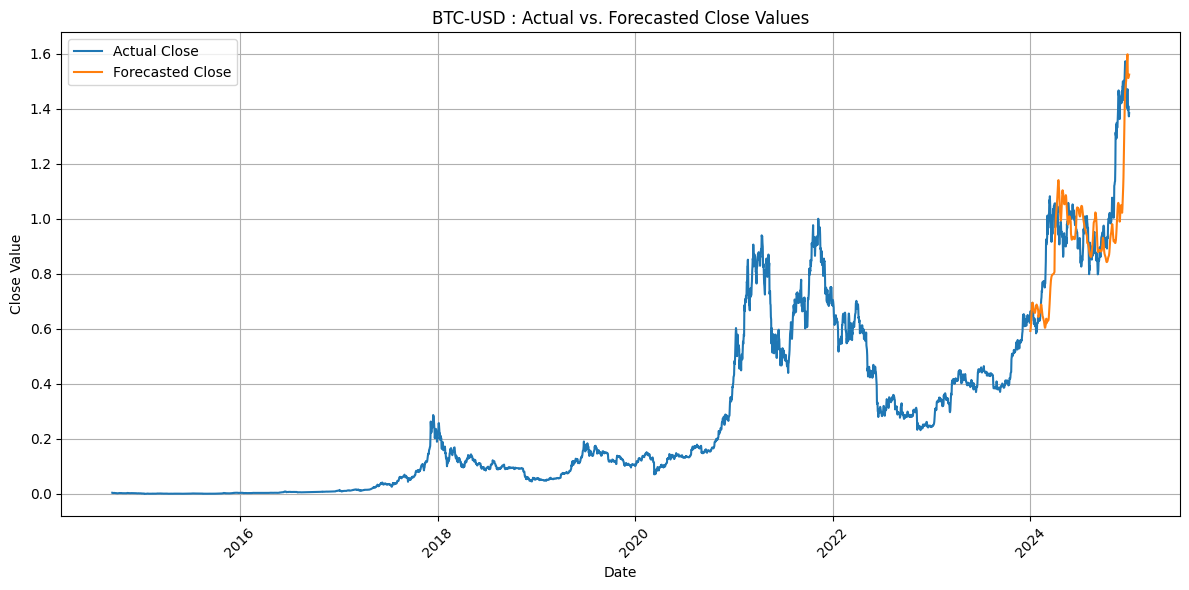

Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Evaluation Metric for BTC-USD_LSTM_30 Scaled
MAPE: 11.82083156419271
ME: 0.048186244810225015
MAE: 0.12190722535512959
MPE: 3.5823790268793267
RMSE: 0.16497553761556985
R: 0.7148499479414735
Scalar Product: 0.012783538242569661
Return Score: 0.547945205479452
Long Return: 0.6105263157894737
Short Return: 0.48
Mean Directional Accuracy: 0.547945205479452
Mean Directional Accuracy Positive: 0.6105263157894737
Mean Directional Accuracy Negative: 0.48
Model initialized: NeuralForecastLSTM
{'batch_size': 32, 'broadcasting': False, 'context_size': 10, 'decoder_hidden_size': 200, 'decoder_layers': 2, 'drop_last_loader': False, 'early_stop_patience_steps': -1, 'encoder_bias': True, 'encoder_dropout': 0.0, 'encoder_hidden_size': 200, 'encoder_n_layers': 2, 'freq': 'YE-DEC', 'futr_exog_list': None, 'inference_input_size': -1, 'input_size': -1, 'learning_rate': 0.001, 'local_scaler_type': None, 'loss': None, 'lr_scheduler': None, 'lr_scheduler_kwargs': None, 'max_steps': 20, 'num_lr_decays': -1, 

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | hist_encoder | LSTM          | 484 K  | train
4 | mlp_decoder  | MLP           | 40.4 K | train
-------------------------------------------------------
524 K     Trainable params
0         Non-trainable params
524 K     Total params
2.098     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

NeuralForecastLSTM model fitted.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

/tmp/ipykernel_242555/869719685.py:121: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_data = pd.concat([train_output_df, test_output_df])


Execution time for forecast_crypto_prices(): 51.036707162857056 seconds


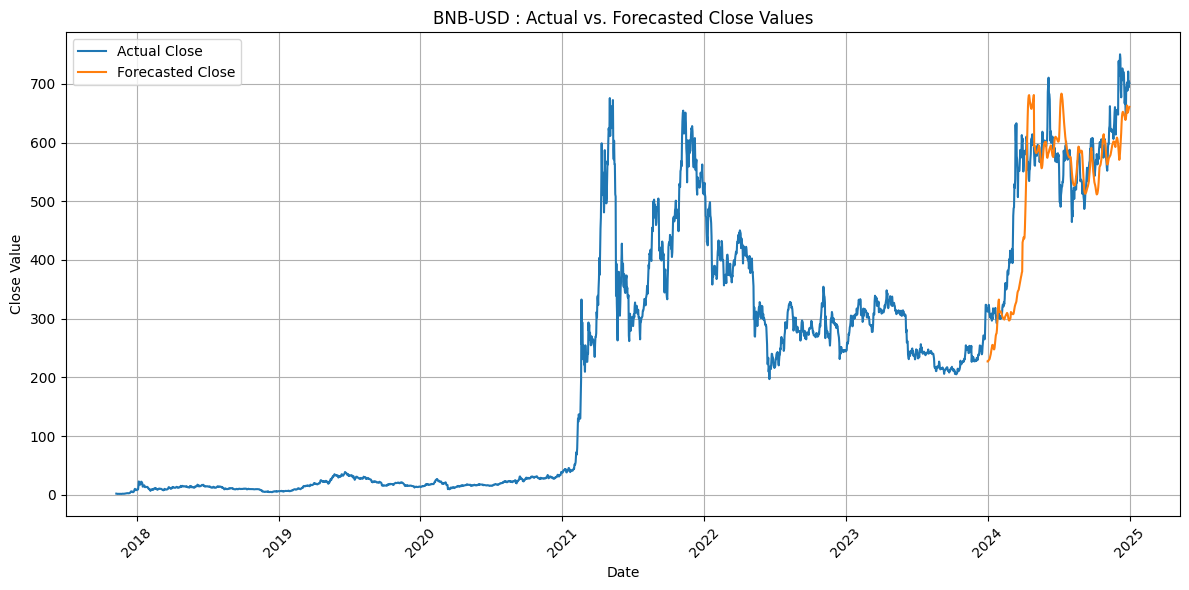

Evaluation Metric for BNB-USD_LSTM_30 Actual Values
MAPE: 10.895365567408703
ME: 28.074311136547983
MAE: 56.940966163176654
MPE: 5.46079055525603
RMSE: 81.64897556934272
R: 0.8118870232546886
Scalar Product: 1923.6096931947368
Return Score: 0.5232876712328767
Long Return: 0.612565445026178
Short Return: 0.42528735632183906
Mean Directional Accuracy: 0.5232876712328767
Mean Directional Accuracy Positive: 0.612565445026178
Mean Directional Accuracy Negative: 0.42528735632183906


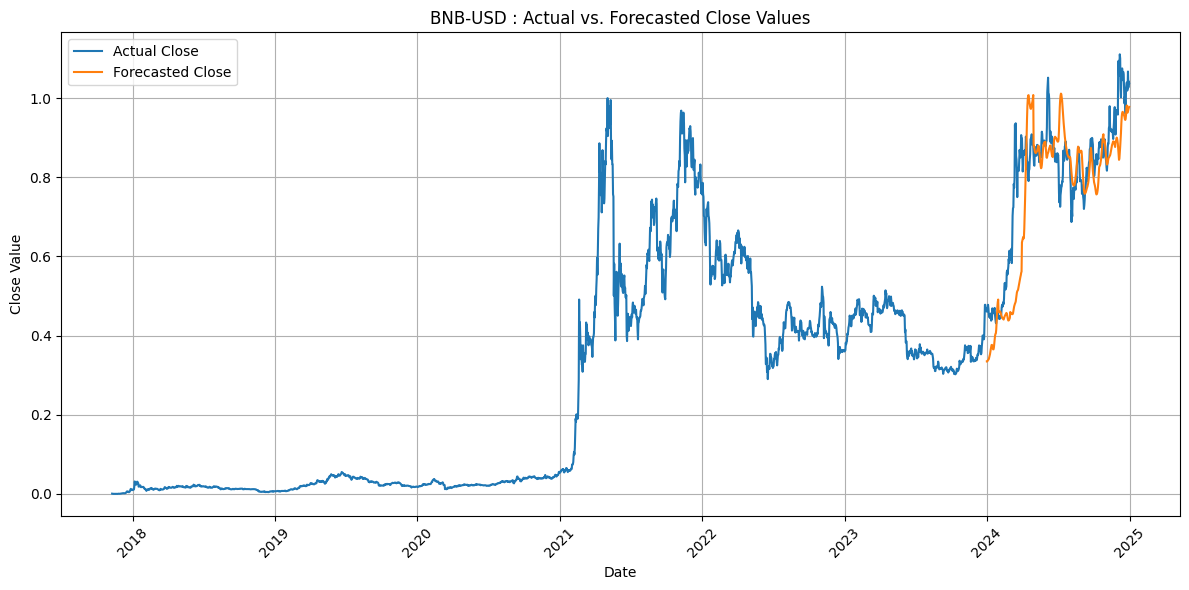

Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Evaluation Metric for BNB-USD_LSTM_30 Scaled
MAPE: 10.929044714080204
ME: 0.04164253478709432
MAE: 0.0844603718116896
MPE: 5.478691748327572
RMSE: 0.121109692975549
R: 0.811887023052418
Scalar Product: 0.00423226171610445
Return Score: 0.5232876712328767
Long Return: 0.612565445026178
Short Return: 0.42528735632183906
Mean Directional Accuracy: 0.5232876712328767
Mean Directional Accuracy Positive: 0.612565445026178
Mean Directional Accuracy Negative: 0.42528735632183906
Model initialized: NeuralForecastLSTM
{'batch_size': 32, 'broadcasting': False, 'context_size': 10, 'decoder_hidden_size': 200, 'decoder_layers': 2, 'drop_last_loader': False, 'early_stop_patience_steps': -1, 'encoder_bias': True, 'encoder_dropout': 0.0, 'encoder_hidden_size': 200, 'encoder_n_layers': 2, 'freq': 'YE-DEC', 'futr_exog_list': None, 'inference_input_size': -1, 'input_size': -1, 'learning_rate': 0.001, 'local_scaler_type': None, 'loss': None, 'lr_scheduler': None, 'lr_scheduler_kwargs': None, 'max_steps': 2

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | hist_encoder | LSTM          | 484 K  | train
4 | mlp_decoder  | MLP           | 40.4 K | train
-------------------------------------------------------
524 K     Trainable params
0         Non-trainable params
524 K     Total params
2.098     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

NeuralForecastLSTM model fitted.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

/tmp/ipykernel_242555/869719685.py:121: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_data = pd.concat([train_output_df, test_output_df])


Execution time for forecast_crypto_prices(): 79.67410945892334 seconds


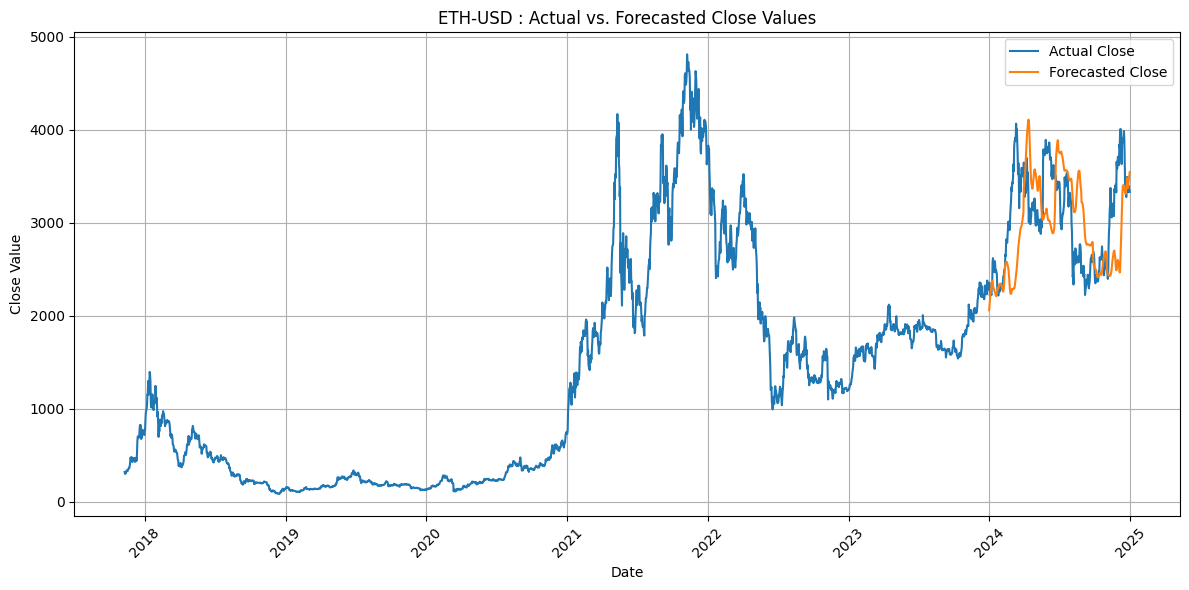

Evaluation Metric for ETH-USD_LSTM_30 Actual Values
MAPE: 14.503753683963874
ME: 91.4410573823856
MAE: 460.0632170797046
MPE: 1.3691833293235915
RMSE: 584.1014176171078
R: 0.35431012098490977
Scalar Product: 28353.939549923
Return Score: 0.4876712328767123
Long Return: 0.49214659685863876
Short Return: 0.4827586206896552
Mean Directional Accuracy: 0.4876712328767123
Mean Directional Accuracy Positive: 0.49214659685863876
Mean Directional Accuracy Negative: 0.4827586206896552


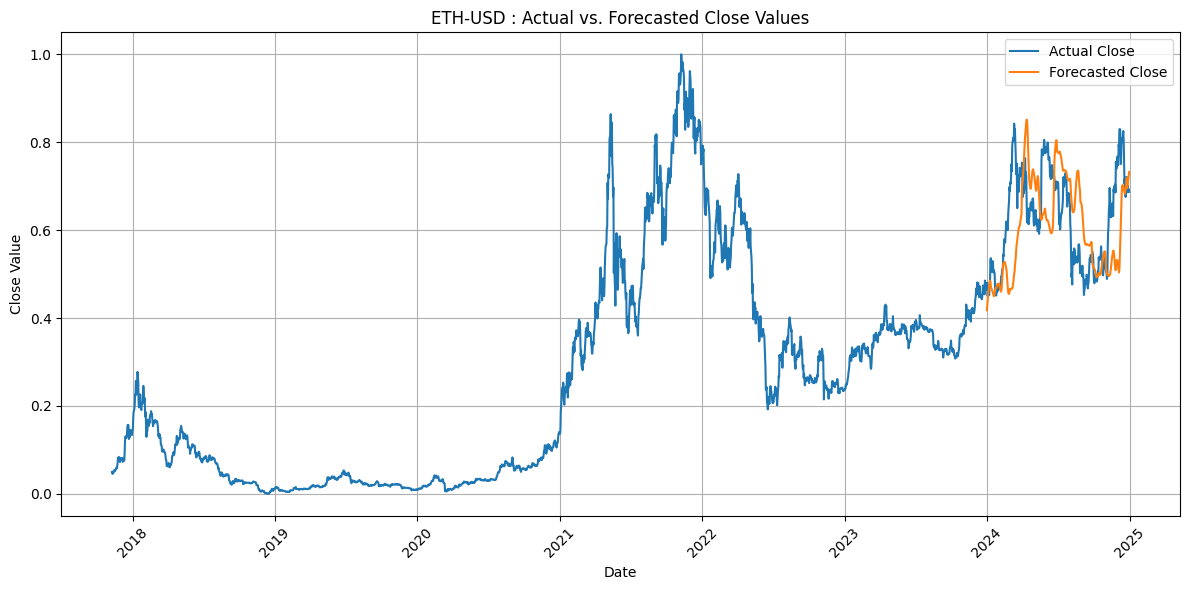

Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | hist_encoder | LSTM          | 484 K  | train
4 | mlp_decoder  | MLP           | 40.4 K | train
-------------------------------------------------------
524 K     Trainable params
0         Non-trainable params
524 K     Total params
2.098     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Evaluation Metric for ETH-USD_LSTM_30 Scaled
MAPE: 14.911639505114424
ME: 0.019341216035356133
MAE: 0.09731064683753861
MPE: 1.3631806852820676
RMSE: 0.12354668415858013
R: 0.3543101148503857
Scalar Product: 0.0012685168641995192
Return Score: 0.4876712328767123
Long Return: 0.49214659685863876
Short Return: 0.4827586206896552
Mean Directional Accuracy: 0.4876712328767123
Mean Directional Accuracy Positive: 0.49214659685863876
Mean Directional Accuracy Negative: 0.4827586206896552
Model initialized: NeuralForecastLSTM
{'batch_size': 32, 'broadcasting': False, 'context_size': 10, 'decoder_hidden_size': 200, 'decoder_layers': 2, 'drop_last_loader': False, 'early_stop_patience_steps': -1, 'encoder_bias': True, 'encoder_dropout': 0.0, 'encoder_hidden_size': 200, 'encoder_n_layers': 2, 'freq': 'YE-DEC', 'futr_exog_list': None, 'inference_input_size': -1, 'input_size': -1, 'learning_rate': 0.001, 'local_scaler_type': None, 'loss': None, 'lr_scheduler': None, 'lr_scheduler_kwargs': None, 'max

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

NeuralForecastLSTM model fitted.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

/tmp/ipykernel_242555/869719685.py:121: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_data = pd.concat([train_output_df, test_output_df])


Execution time for forecast_crypto_prices(): 113.46013689041138 seconds


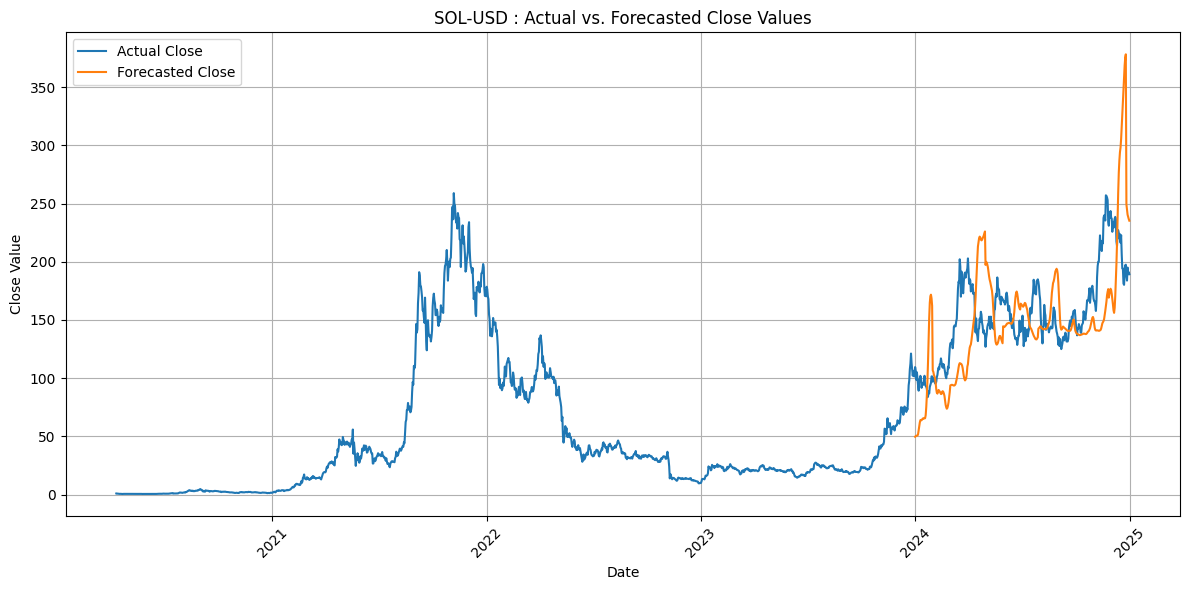

Evaluation Metric for SOL-USD_LSTM_30 Actual Values
MAPE: 24.35853115334395
ME: 7.219762687474652
MAE: 38.458273986649644
MPE: 3.261287619925072
RMSE: 49.240994381203386
R: 0.45046541418327857
Scalar Product: 1082.1769078342522
Return Score: 0.5178082191780822
Long Return: 0.585635359116022
Short Return: 0.45108695652173914
Mean Directional Accuracy: 0.5178082191780822
Mean Directional Accuracy Positive: 0.585635359116022
Mean Directional Accuracy Negative: 0.45108695652173914


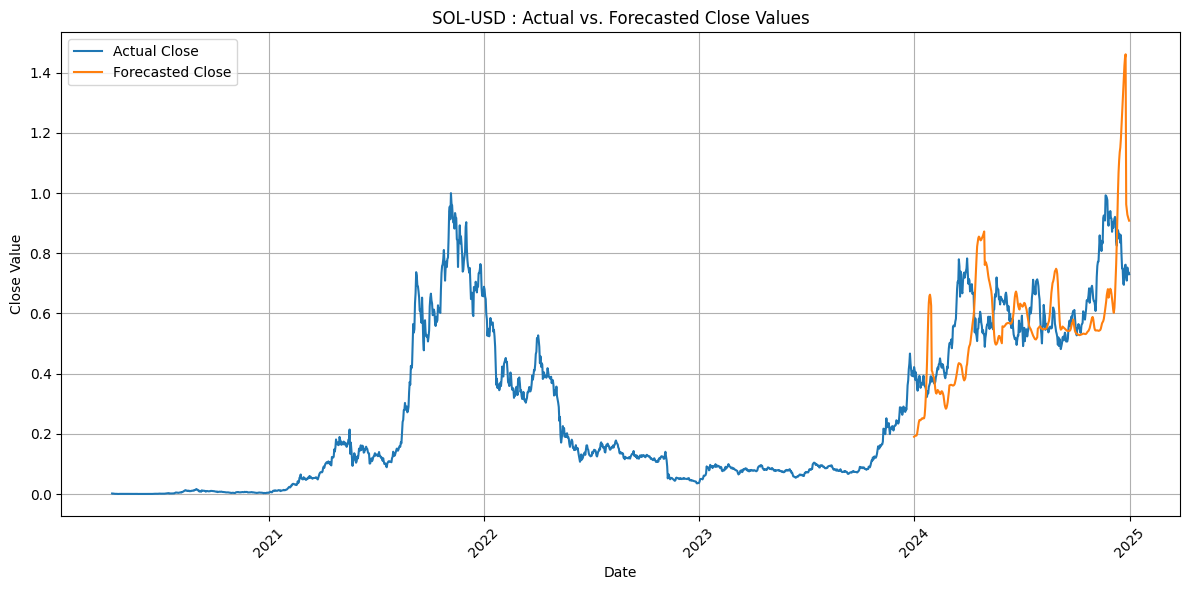

Evaluation Metric for SOL-USD_LSTM_30 Scaled
MAPE: 24.444603231806514
ME: 0.02793820468646869
MAE: 0.1488213610140446
MPE: 3.2693789934457076
RMSE: 0.19054708074586663
R: 0.4504654156485812
Scalar Product: 0.01620501126449818
Return Score: 0.5178082191780822
Long Return: 0.585635359116022
Short Return: 0.45108695652173914
Mean Directional Accuracy: 0.5178082191780822
Mean Directional Accuracy Positive: 0.585635359116022
Mean Directional Accuracy Negative: 0.45108695652173914


25083

In [8]:
forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 30, freq='D', scaling = 'm')
gc.collect()